# Premier League Data Analytics Pipeline

In [105]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

In [106]:
df_raw = pd.read_csv('E0.csv')
df_raw.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,16/08/2024,20:00,Man United,Fulham,1,0,H,0,0,...,1.86,2.07,1.83,2.11,1.88,2.11,1.82,2.05,1.90,2.08
1,E0,17/08/2024,12:30,Ipswich,Liverpool,0,2,A,0,0,...,2.05,1.88,2.04,1.90,2.20,2.00,1.99,1.88,2.04,1.93
2,E0,17/08/2024,15:00,Arsenal,Wolves,2,0,H,1,0,...,2.02,1.91,2.00,1.90,2.05,1.93,1.99,1.87,2.02,1.96
3,E0,17/08/2024,15:00,Everton,Brighton,0,3,A,0,1,...,1.87,2.06,1.86,2.07,1.92,2.10,1.83,2.04,1.88,2.11
4,E0,17/08/2024,15:00,Newcastle,Southampton,1,0,H,1,0,...,1.87,2.06,1.88,2.06,1.89,2.10,1.82,2.05,1.89,2.10


## 1. Data Cleaning & Domain Logic

In [107]:
df_clean = df_raw[['Date', 'HomeTeam', 'AwayTeam', 'FTHG',
'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 
'AC', 'HY', 'AY', 'HR', 'AR']].copy()

df_clean.rename(columns={'FTHG': 'FullTimeHomeGoals', 'FTAG': 'FullTimeAwayGoals',
'HS': 'HomeShots', 'AS': 'AwayShots', 'HST': 'HomeShotsOnTarget',
'AST': 'AwayShotsOnTarget', 'HF': 'HomeFouls', 'AF': 'AwayFouls',
'HC': 'HomeCorners', 'AC': 'AwayCorners', 'HY': 'HomeYellowCards', 'AY': 'AwayYellowCards',
'HR': 'HomeRedCards', 'AR': 'AwayRedCards'}, inplace=True)

df_clean.dropna(inplace=True)

total_goals = df_clean['FullTimeHomeGoals'] + df_clean['FullTimeAwayGoals']
df_clean.insert(5, 'TotalGoals', total_goals, True)

conditions = [
    (df_clean['FullTimeHomeGoals'] > df_clean['FullTimeAwayGoals']),
    ((df_clean['FullTimeHomeGoals'] < df_clean['FullTimeAwayGoals'])),
    (df_clean['FullTimeHomeGoals'] == df_clean['FullTimeAwayGoals'])
]
choices = [3, 0, 1]
df_clean['HomePoints'] = np.select(conditions, choices)

choices2 = [0, 3, 1]
df_clean['AwayPoints'] = np.select(conditions, choices2)

df_clean.head()

,Date,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,TotalGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeFouls,AwayFouls,HomeCorners,AwayCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,HomePoints,AwayPoints
0,16/08/2024,Man United,Fulham,1,0,1,14,10,5,2,12,10,7,8,2,3,0,0,3,0
1,17/08/2024,Ipswich,Liverpool,0,2,2,7,18,2,5,9,18,2,10,3,1,0,0,0,3
2,17/08/2024,Arsenal,Wolves,2,0,2,18,9,6,3,17,14,8,2,2,2,0,0,3,0
3,17/08/2024,Everton,Brighton,0,3,3,9,10,1,5,8,8,1,5,1,1,1,0,0,3
4,17/08/2024,Newcastle,Southampton,1,0,1,3,19,1,4,15,16,3,12,2,4,1,0,3,0


## 2. Dimensional Modeling

In [108]:
df_final = df_clean.copy()
teams = df_clean['HomeTeam'].unique()

df_teams = pd.DataFrame()
df_teams['TeamID'] = range(len(teams))
df_teams['TeamName'] = teams

team_mapping = df_teams.set_index('TeamName')['TeamID'].to_dict()
df_final['HomeTeam'] = df_final['HomeTeam'].map(team_mapping)
df_final['AwayTeam'] = df_final['AwayTeam'].map(team_mapping)
df_final.rename(columns={'HomeTeam': 'HomeTeamID', 'AwayTeam': 'AwayTeamID'}, inplace=True)
df_final.head()

,Date,HomeTeamID,AwayTeamID,FullTimeHomeGoals,FullTimeAwayGoals,TotalGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeFouls,AwayFouls,HomeCorners,AwayCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,HomePoints,AwayPoints
0,16/08/2024,0,12,1,0,1,14,10,5,2,12,10,7,8,2,3,0,0,3,0
1,17/08/2024,1,19,0,2,2,7,18,2,5,9,18,2,10,3,1,0,0,0,3
2,17/08/2024,2,18,2,0,2,18,9,6,3,17,14,8,2,2,2,0,0,3,0
3,17/08/2024,3,10,0,3,3,9,10,1,5,8,8,1,5,1,1,1,0,0,3
4,17/08/2024,4,14,1,0,1,3,19,1,4,15,16,3,12,2,4,1,0,3,0


## 3. Advanced Aggregation (Standings)

In [109]:
home_stats = df_final[['HomeTeamID', 'HomePoints', 'FullTimeHomeGoals', 'FullTimeAwayGoals']].copy()
home_stats.rename(columns={'HomeTeamID': 'TeamID', 'HomePoints': 'Points', 'FullTimeHomeGoals': 'GoalsFor',
'FullTimeAwayGoals': 'GoalsAgainst'}, inplace=True)
away_stats = df_final[['AwayTeamID', 'AwayPoints', 'FullTimeAwayGoals', 'FullTimeHomeGoals']].copy()
away_stats.rename(columns={'AwayTeamID': 'TeamID', 'AwayPoints': 'Points', 'FullTimeAwayGoals': 'GoalsFor',
'FullTimeHomeGoals': 'GoalsAgainst'}, inplace=True)

all_stats = pd.concat([home_stats, away_stats])

df_standings = all_stats.groupby('TeamID').sum().reset_index()
df_standings['GoalDifference'] = df_standings['GoalsFor'] - df_standings['GoalsAgainst']
df_standings.sort_values(by=['Points', 'GoalDifference', 'GoalsFor'], ascending=[False, False, False], inplace=True)
df_standings.insert(0, 'Position', range(1, 21), True)

bins = [0, 5, 10, 17, 20]
names = ['Top 5', 'Positions 6-10', 'Positions 11-17', 'Relegation zone']
df_standings['Tier'] = pd.cut(df_standings['Position'], bins=bins, labels=names)
df_standings

,Position,TeamID,Points,GoalsFor,GoalsAgainst,GoalDifference,Tier
19,1,19,84,86,41,45,Top 5
2,2,2,74,69,34,35,Top 5
13,3,13,71,72,44,28,Top 5
8,4,8,69,64,43,21,Top 5
4,5,4,66,68,47,21,Top 5
16,6,16,66,58,51,7,Positions 6-10
5,7,5,65,58,46,12,Positions 6-10
10,8,10,61,66,59,7,Positions 6-10
17,9,17,56,58,46,12,Positions 6-10
7,10,7,56,66,57,9,Positions 6-10


## 4. Database Export (Star Schema)

In [110]:
engine = create_engine('sqlite:///premier_league.db')
df_final.to_sql('Matches', con=engine, index=False, if_exists='replace')
df_teams.to_sql('Teams', con=engine, index=False, if_exists='replace')
df_standings.to_sql('Standings', con=engine, index=False, if_exists='replace')

20

## 5. Analytics & Visualization

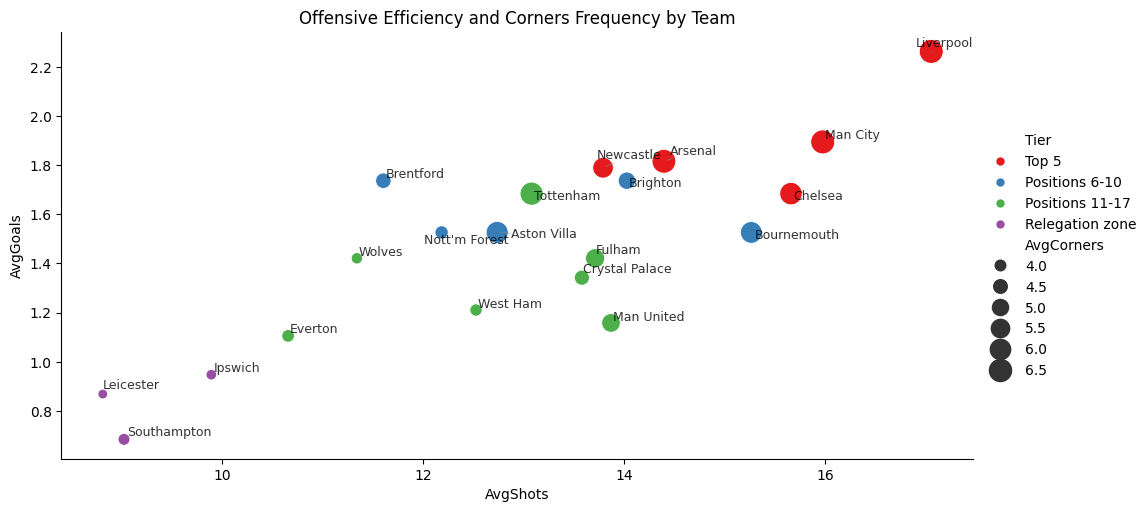

In [115]:
query_shots_corelation = """
with AllMatches as(
select HomeTeamID as TeamID, FullTimeHomeGoals AS Goals, HomeShots as Shots, HomeCorners as Corners
from Matches
union all
select AwayTeamID as TeamID, FullTimeAwayGoals AS Goals, AwayShots as Shots, AwayCorners as Corners
from Matches
)
select T.TeamName, S.Tier, avg(AM.Goals) as AvgGoals, avg(AM.Shots) as AvgShots, avg(AM.Corners) as AvgCorners
from AllMatches AM
join Teams T on AM.TeamID=T.TeamID
join Standings S on AM.TeamID=S.TeamID
group by T.TeamName, S.Tier;
"""

df_shots_corelation = pd.read_sql(query_shots_corelation, engine)

plot = sns.relplot(data=df_shots_corelation, x='AvgShots',
y='AvgGoals', hue='Tier',
size='AvgCorners', aspect=2, sizes=(50, 300), palette='Set1')

texts = []
for i in range(df_shots_corelation.shape[0]):
    texts.append(
        plt.text(
            x=df_shots_corelation.AvgShots[i],
            y=df_shots_corelation.AvgGoals[i],
            s=df_shots_corelation.TeamName[i],
            fontsize=9,
            alpha=0.8
        )
    )

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
plt.title("Offensive Efficiency and Corners Frequency by Team")
plt.show()